In [52]:
import pandas as pd
import seaborn as sns
pd.options.display.max_rows = 10

In [53]:
gdp = pd.read_csv("gdp.csv")
gdp["gdp"] = gdp["GDP (constant 2010 US$)"] / 1_000_000_000

In [54]:
import plotly.express as px
px.line(gdp, x = "Year", y = "gdp", color = "Entity")

In [55]:
pop = pd.read_csv("population.csv")

In [56]:
pop

,Entity,Code,Year,"Total population (Gapminder, HYDE & UN)"
0,Afghanistan,AFG,1800,3280000
1,Afghanistan,AFG,1801,3280000
2,Afghanistan,AFG,1802,3280000
3,Afghanistan,AFG,1803,3280000
4,Afghanistan,AFG,1804,3280000
...,...,...,...,...
46878,Zimbabwe,ZWE,2015,13815000
46879,Zimbabwe,ZWE,2016,14030000
46880,Zimbabwe,ZWE,2017,14237000
46881,Zimbabwe,ZWE,2018,14439000


In [57]:
px.line(pop.query("Year > 1900"), x = "Year", y = "Total population (Gapminder, HYDE & UN)", color = "Entity")

In [58]:
pop = pop.rename(columns = {"Total population (Gapminder, HYDE & UN)" : "population"})

In [59]:
pop

,Entity,Code,Year,population
0,Afghanistan,AFG,1800,3280000
1,Afghanistan,AFG,1801,3280000
2,Afghanistan,AFG,1802,3280000
3,Afghanistan,AFG,1803,3280000
4,Afghanistan,AFG,1804,3280000
...,...,...,...,...
46878,Zimbabwe,ZWE,2015,13815000
46879,Zimbabwe,ZWE,2016,14030000
46880,Zimbabwe,ZWE,2017,14237000
46881,Zimbabwe,ZWE,2018,14439000


In [60]:
gdp2017 = gdp.query("Year == 2017")

In [61]:
pop2017 = pop.query("Year == 2017")
pop2017

,Entity,Code,Year,population
217,Afghanistan,AFG,2017,36296000
339,Africa,NaN,2017,1244221952
559,Albania,ALB,2017,2884000
779,Algeria,DZA,2017,41389000
849,American Samoa,ASM,2017,56000
...,...,...,...,...
46069,Western Sahara,ESH,2017,553000
46220,World,OWID_WRL,2017,7547858944
46440,Yemen,YEM,2017,27835000
46660,Zambia,ZMB,2017,16854000


In [62]:
gdp_and_pop_2017 = pd.merge(left = gdp2017, right = pop2017, left_on = "Entity", right_on = "Entity", how = "left")
gdp_and_pop_2017

,Entity,Code_x,Year_x,GDP (constant 2010 US$),gdp,Code_y,Year_y,population
0,Afghanistan,AFG,2017,2.196941e+10,21.969414,AFG,2017.0,36296000.0
1,Albania,ALB,2017,1.398856e+10,13.988556,ALB,2017.0,2884000.0
2,Algeria,DZA,2017,1.993674e+11,199.367414,DZA,2017.0,41389000.0
3,Andorra,AND,2017,3.382068e+09,3.382068,AND,2017.0,77000.0
4,Angola,AGO,2017,1.037860e+11,103.785984,AGO,2017.0,29817000.0
...,...,...,...,...,...,...,...,...
180,Uzbekistan,UZB,2017,6.577995e+10,65.779950,UZB,2017.0,31960000.0
181,Vanuatu,VUT,2017,8.120250e+08,0.812025,VUT,2017.0,285000.0
182,Vietnam,VNM,2017,1.752841e+11,175.284081,VNM,2017.0,94601000.0
183,Zambia,ZMB,2017,2.813940e+10,28.139397,ZMB,2017.0,16854000.0


In [63]:
gdp_and_pop_2017["gdp_per_capita"] = gdp_and_pop_2017["GDP (constant 2010 US$)"] / gdp_and_pop_2017["population"]
gdp_and_pop_2017

,Entity,Code_x,Year_x,GDP (constant 2010 US$),gdp,Code_y,Year_y,population,gdp_per_capita
0,Afghanistan,AFG,2017,2.196941e+10,21.969414,AFG,2017.0,36296000.0,605.284718
1,Albania,ALB,2017,1.398856e+10,13.988556,ALB,2017.0,2884000.0,4850.400743
2,Algeria,DZA,2017,1.993674e+11,199.367414,DZA,2017.0,41389000.0,4816.917876
3,Andorra,AND,2017,3.382068e+09,3.382068,AND,2017.0,77000.0,43922.964124
4,Angola,AGO,2017,1.037860e+11,103.785984,AGO,2017.0,29817000.0,3480.765485
...,...,...,...,...,...,...,...,...,...
180,Uzbekistan,UZB,2017,6.577995e+10,65.779950,UZB,2017.0,31960000.0,2058.196177
181,Vanuatu,VUT,2017,8.120250e+08,0.812025,VUT,2017.0,285000.0,2849.210379
182,Vietnam,VNM,2017,1.752841e+11,175.284081,VNM,2017.0,94601000.0,1852.877677
183,Zambia,ZMB,2017,2.813940e+10,28.139397,ZMB,2017.0,16854000.0,1669.597527


In [64]:
px.bar(gdp_and_pop_2017.sort_values("gdp_per_capita"), x = "Entity", y = "gdp_per_capita")

In [65]:
gdp_and_pop_2017.query('Entity == "Kosovo"')

,Entity,Code_x,Year_x,GDP (constant 2010 US$),gdp,Code_y,Year_y,population,gdp_per_capita
87,Kosovo,OWID_KOS,2017,7.447672e+09,7.447672,NaN,NaN,NaN,NaN


In [66]:
set(gdp2017["Entity"]) - set(pop2017["Entity"])

{'Kosovo'}

In [67]:
gdp_and_pop_2017

,Entity,Code_x,Year_x,GDP (constant 2010 US$),gdp,Code_y,Year_y,population,gdp_per_capita
0,Afghanistan,AFG,2017,2.196941e+10,21.969414,AFG,2017.0,36296000.0,605.284718
1,Albania,ALB,2017,1.398856e+10,13.988556,ALB,2017.0,2884000.0,4850.400743
2,Algeria,DZA,2017,1.993674e+11,199.367414,DZA,2017.0,41389000.0,4816.917876
3,Andorra,AND,2017,3.382068e+09,3.382068,AND,2017.0,77000.0,43922.964124
4,Angola,AGO,2017,1.037860e+11,103.785984,AGO,2017.0,29817000.0,3480.765485
...,...,...,...,...,...,...,...,...,...
180,Uzbekistan,UZB,2017,6.577995e+10,65.779950,UZB,2017.0,31960000.0,2058.196177
181,Vanuatu,VUT,2017,8.120250e+08,0.812025,VUT,2017.0,285000.0,2849.210379
182,Vietnam,VNM,2017,1.752841e+11,175.284081,VNM,2017.0,94601000.0,1852.877677
183,Zambia,ZMB,2017,2.813940e+10,28.139397,ZMB,2017.0,16854000.0,1669.597527


In [68]:
gdp_and_pop_2017.sort_values("gdp_per_capita")

,Entity,Code_x,Year_x,GDP (constant 2010 US$),gdp,Code_y,Year_y,population,gdp_per_capita
27,Burundi,BDI,2017,2.309167e+09,2.309167,BDI,2017.0,10827000.0,213.278588
32,Central African Republic,CAF,2017,1.560913e+09,1.560913,CAF,2017.0,4596000.0,339.624311
94,Liberia,LBR,2017,1.666984e+09,1.666984,LBR,2017.0,4702000.0,354.526588
121,Niger,NER,2017,8.503683e+09,8.503683,NER,2017.0,21602000.0,393.652575
44,Democratic Republic of Congo,COD,2017,3.327760e+10,33.277602,COD,2017.0,81399000.0,408.820771
...,...,...,...,...,...,...,...,...,...
78,Ireland,IRL,2017,3.582935e+11,358.293478,IRL,2017.0,4753000.0,75382.595752
162,Switzerland,CHE,2017,6.490679e+11,649.067885,CHE,2017.0,8456000.0,76758.264497
124,Norway,NOR,2017,4.818371e+11,481.837084,NOR,2017.0,5296000.0,90981.322561
97,Luxembourg,LUX,2017,6.465973e+10,64.659730,LUX,2017.0,592000.0,109222.517488


In [69]:
pop

,Entity,Code,Year,population
0,Afghanistan,AFG,1800,3280000
1,Afghanistan,AFG,1801,3280000
2,Afghanistan,AFG,1802,3280000
3,Afghanistan,AFG,1803,3280000
4,Afghanistan,AFG,1804,3280000
...,...,...,...,...
46878,Zimbabwe,ZWE,2015,13815000
46879,Zimbabwe,ZWE,2016,14030000
46880,Zimbabwe,ZWE,2017,14237000
46881,Zimbabwe,ZWE,2018,14439000


In [70]:
gdp_and_pop = pd.merge(left = gdp, right = pop, left_on = ["Entity", "Year"], right_on = ["Entity", "Year"], how = "inner")
gdp_and_pop

,Entity,Code_x,Year,GDP (constant 2010 US$),gdp,Code_y,population
0,Afghanistan,AFG,2002,8.013233e+09,8.013233,AFG,22601000
1,Afghanistan,AFG,2003,8.689884e+09,8.689884,AFG,23681000
2,Afghanistan,AFG,2004,8.781610e+09,8.781610,AFG,24727000
3,Afghanistan,AFG,2005,9.762979e+09,9.762979,AFG,25654000
4,Afghanistan,AFG,2006,1.030523e+10,10.305228,AFG,26433000
...,...,...,...,...,...,...,...
8846,Zimbabwe,ZWE,2013,1.418193e+10,14.181927,ZWE,13350000
8847,Zimbabwe,ZWE,2014,1.448359e+10,14.483588,ZWE,13587000
8848,Zimbabwe,ZWE,2015,1.472830e+10,14.728302,ZWE,13815000
8849,Zimbabwe,ZWE,2016,1.481899e+10,14.818986,ZWE,14030000


In [71]:
gdp_and_pop["gdp_per_capita"] = gdp_and_pop["GDP (constant 2010 US$)"] / gdp_and_pop["population"]

In [72]:
gdp_and_pop

,Entity,Code_x,Year,GDP (constant 2010 US$),gdp,Code_y,population,gdp_per_capita
0,Afghanistan,AFG,2002,8.013233e+09,8.013233,AFG,22601000,354.552149
1,Afghanistan,AFG,2003,8.689884e+09,8.689884,AFG,23681000,366.955940
2,Afghanistan,AFG,2004,8.781610e+09,8.781610,AFG,24727000,355.142564
3,Afghanistan,AFG,2005,9.762979e+09,9.762979,AFG,25654000,380.563610
4,Afghanistan,AFG,2006,1.030523e+10,10.305228,AFG,26433000,389.862222
...,...,...,...,...,...,...,...,...
8846,Zimbabwe,ZWE,2013,1.418193e+10,14.181927,ZWE,13350000,1062.316603
8847,Zimbabwe,ZWE,2014,1.448359e+10,14.483588,ZWE,13587000,1065.988675
8848,Zimbabwe,ZWE,2015,1.472830e+10,14.728302,ZWE,13815000,1066.109450
8849,Zimbabwe,ZWE,2016,1.481899e+10,14.818986,ZWE,14030000,1056.235654


In [73]:
px.line(gdp_and_pop, x = "Year", y = "gdp_per_capita", color = "Entity")

In [74]:
gdp_and_pop_by_entity = gdp_and_pop.set_index("Entity")

In [75]:
gdp_and_pop_by_entity["gdp_per_cap_ratio"] = gdp_and_pop_by_entity["gdp_per_capita"] / gdp_and_pop_by_entity.query("Year == 1960")["gdp_per_capita"]

In [76]:
gdp_and_pop = gdp_and_pop_by_entity.reset_index()

In [77]:
gdp_per_cap_ratio_history = gdp_and_pop.dropna()

In [78]:
px.line(gdp_per_cap_ratio_history, x = "Year", y = "gdp_per_cap_ratio", color = "Entity")

In [79]:
gdp_and_pop_by_entity = gdp_per_cap_ratio_history.set_index("Entity")
gdp_and_pop_by_entity["pop_ratio"] = gdp_and_pop_by_entity["population"] / gdp_and_pop_by_entity.query("Year == 1960")["population"]
gdp_and_pop_by_entity["gdp_ratio"] = gdp_and_pop_by_entity["gdp"] / gdp_and_pop_by_entity.query("Year == 1960")["gdp"]
gdp_and_pop = gdp_and_pop_by_entity.reset_index()

In [80]:
gdp_and_pop

,Entity,Code_x,Year,GDP (constant 2010 US$),gdp,Code_y,population,gdp_per_capita,gdp_per_cap_ratio,pop_ratio,gdp_ratio
0,Algeria,DZA,1960,2.743440e+10,27.434399,DZA,11058000,2480.954892,1.000000,1.000000,1.000000
1,Algeria,DZA,1961,2.370183e+10,23.701828,DZA,11336000,2090.845811,0.842758,1.025140,0.863946
2,Algeria,DZA,1962,1.903611e+10,19.036113,DZA,11620000,1638.219736,0.660318,1.050823,0.693878
3,Algeria,DZA,1963,2.556811e+10,25.568114,DZA,11913000,2146.236350,0.865085,1.077320,0.931973
4,Algeria,DZA,1964,2.706114e+10,27.061141,DZA,12222000,2214.133643,0.892452,1.105263,0.986395
...,...,...,...,...,...,...,...,...,...,...,...
5207,Zimbabwe,ZWE,2013,1.418193e+10,14.181927,ZWE,13350000,1062.316603,1.192968,3.534551,4.216605
5208,Zimbabwe,ZWE,2014,1.448359e+10,14.483588,ZWE,13587000,1065.988675,1.197091,3.597299,4.306296
5209,Zimbabwe,ZWE,2015,1.472830e+10,14.728302,ZWE,13815000,1066.109450,1.197227,3.657665,4.379055
5210,Zimbabwe,ZWE,2016,1.481899e+10,14.818986,ZWE,14030000,1056.235654,1.186139,3.714588,4.406017


In [81]:
px.line(gdp_and_pop, x = "Year", y = "pop_ratio", color = "Entity")

In [82]:
px.scatter(gdp_and_pop.query("Year == 2017"), x = "gdp_per_cap_ratio", y = "pop_ratio", color = "Entity")

In [83]:
px.scatter(gdp_and_pop.query("Year == 2017"), x = "gdp_per_cap_ratio", y = "pop_ratio", color = "Entity", size = "gdp_ratio")

In [84]:
#Exercise suggestion: 1960 vs 2017 GDP by using merge

### Adding Life Expectancy Data

In [85]:
life_exp = pd.read_csv("life_expectancy.csv")
life_exp

,Entity,Code,Year,Life expectancy
0,Afghanistan,AFG,1950,27.638
1,Afghanistan,AFG,1951,27.878
2,Afghanistan,AFG,1952,28.361
3,Afghanistan,AFG,1953,28.852
4,Afghanistan,AFG,1954,29.350
...,...,...,...,...
18440,Zimbabwe,ZWE,2015,59.534
18441,Zimbabwe,ZWE,2016,60.294
18442,Zimbabwe,ZWE,2017,60.812
18443,Zimbabwe,ZWE,2018,61.195


In [86]:
life_exp = life_exp[["Entity", "Year", "Life expectancy"]]

In [87]:
gdp_pop_le = pd.merge(left = gdp_and_pop, right = life_exp, left_on = ["Entity", "Year"], right_on = ["Entity", "Year"], how = "left")

In [88]:
gdp_pop_le

,Entity,Code_x,Year,GDP (constant 2010 US$),gdp,Code_y,population,gdp_per_capita,gdp_per_cap_ratio,pop_ratio,gdp_ratio,Life expectancy
0,Algeria,DZA,1960,2.743440e+10,27.434399,DZA,11058000,2480.954892,1.000000,1.000000,1.000000,46.141
1,Algeria,DZA,1961,2.370183e+10,23.701828,DZA,11336000,2090.845811,0.842758,1.025140,0.863946,46.599
2,Algeria,DZA,1962,1.903611e+10,19.036113,DZA,11620000,1638.219736,0.660318,1.050823,0.693878,47.056
3,Algeria,DZA,1963,2.556811e+10,25.568114,DZA,11913000,2146.236350,0.865085,1.077320,0.931973,47.509
4,Algeria,DZA,1964,2.706114e+10,27.061141,DZA,12222000,2214.133643,0.892452,1.105263,0.986395,47.958
...,...,...,...,...,...,...,...,...,...,...,...,...
5207,Zimbabwe,ZWE,2013,1.418193e+10,14.181927,ZWE,13350000,1062.316603,1.192968,3.534551,4.216605,56.897
5208,Zimbabwe,ZWE,2014,1.448359e+10,14.483588,ZWE,13587000,1065.988675,1.197091,3.597299,4.306296,58.410
5209,Zimbabwe,ZWE,2015,1.472830e+10,14.728302,ZWE,13815000,1066.109450,1.197227,3.657665,4.379055,59.534
5210,Zimbabwe,ZWE,2016,1.481899e+10,14.818986,ZWE,14030000,1056.235654,1.186139,3.714588,4.406017,60.294


In [89]:
px.scatter(gdp_pop_le.query("Year == 2017"), x = "gdp_per_capita", 
           y = "Life expectancy", color = "Entity")

In [90]:
px.scatter(gdp_pop_le.query("Year == 2017"), x = "gdp_per_capita", 
           y = "Life expectancy", color = "Entity", log_x = True)

In [91]:
gdp_pop_le_with_log_gdp = gdp_pop_le.copy()

In [92]:
import numpy as np
gdp_pop_le_with_log_gdp["log_10_gdp_per_capita"] = np.log10(gdp_pop_le_with_log_gdp["gdp_per_capita"])

In [93]:
fig = px.scatter(gdp_pop_le_with_log_gdp.query("Year == 2017"), x = "log_10_gdp_per_capita", 
           y = "Life expectancy", trendline = "ols")
fig.show()

### Histograms, KDE Plots, Violin Plots, Box Plots

In [94]:
px.histogram(gdp_pop_le.query("Year == 2017")["Life expectancy"])
# maybe show line

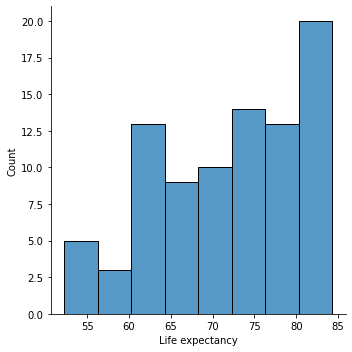

In [95]:
sns.displot(gdp_pop_le.query("Year == 2017")["Life expectancy"])

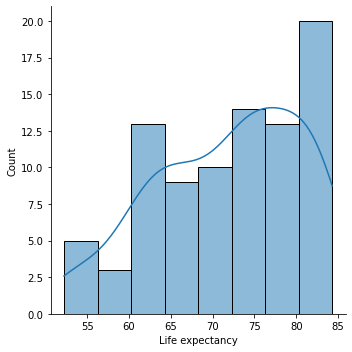

In [96]:
sns.displot(gdp_pop_le.query("Year == 2017")["Life expectancy"], kde = True)

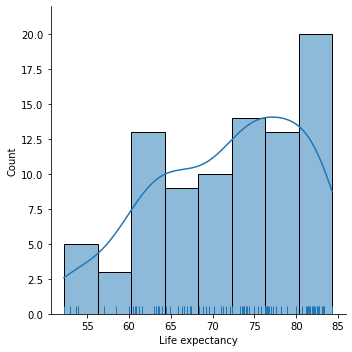

In [97]:
sns.displot(gdp_pop_le.query("Year == 2017")["Life expectancy"], kde = True, rug = True)

In [98]:
px.violin(gdp_pop_le.query("Year == 2017")["Life expectancy"])

In [99]:
px.violin(gdp_pop_le.query("Year == 2017")["Life expectancy"], points = "all")

In [100]:
continents = pd.read_csv("continents.csv")
continents

,Country,Continent
0,Algeria,Africa
1,Angola,Africa
2,Benin,Africa
3,Botswana,Africa
4,Burkina Faso,Africa
...,...,...
197,Paraguay,South America
198,Peru,South America
199,Suriname,South America
200,Uruguay,South America


In [101]:
gdp_pop_le = pd.merge(left = gdp_pop_le, right = continents, left_on = "Entity", 
                      right_on = "Country", how = "left")

In [102]:
continents = ["Africa",  "Europe"]
px.violin(gdp_pop_le.query("Year == 2017 and Continent in @continents").dropna(), y = "Life expectancy",
          color = "Continent")

In [103]:
continents = ["Africa",  "Europe"]
px.box(gdp_pop_le.query("Year == 2017 and Continent in @continents").dropna(), y = "Life expectancy",
          color = "Continent")

In [104]:
px.box(gdp_pop_le.query("Year == 2017").dropna(), y = "Life expectancy",
          color = "Continent")

In [105]:
px.scatter(gdp_pop_le.query("Year == 2017"), x = "gdp_per_capita", 
           y = "Life expectancy",
           marginal_y = "histogram", marginal_x = "histogram")

In [106]:
px.scatter(gdp_pop_le.query("Year == 2017"), x = "gdp_per_capita", 
           y = "Life expectancy",
           marginal_y = "box", marginal_x = "box")

In [107]:
px.density_heatmap(gdp_pop_le.query("Year == 2017"), x = "gdp_per_capita", 
           y = "Life expectancy", marginal_x = "histogram", marginal_y = "histogram")

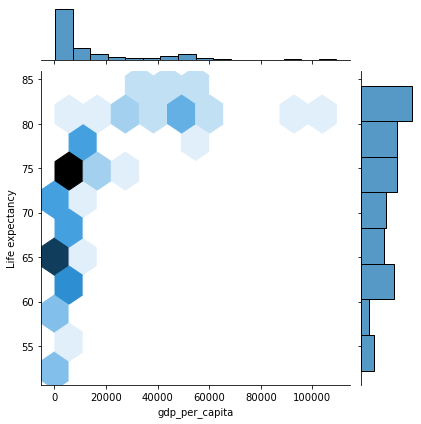

In [108]:
sns.jointplot(data = gdp_pop_le.query("Year == 2017"), x = "gdp_per_capita", 
           y = "Life expectancy", kind = "hex")

### String Data

In [109]:
gdp_pop_le[gdp_pop_le["Entity"].str.contains("in")]

,Entity,Code_x,Year,GDP (constant 2010 US$),gdp,Code_y,population,gdp_per_capita,gdp_per_cap_ratio,pop_ratio,gdp_ratio,Life expectancy,Country,Continent
58,Argentina,ARG,1960,1.155739e+11,115.573869,ARG,20482000,5642.704253,1.000000,1.000000,1.000000,65.055,Argentina,South America
59,Argentina,ARG,1961,1.218470e+11,121.847037,ARG,20817000,5853.246697,1.037312,1.016356,1.054278,65.176,Argentina,South America
60,Argentina,ARG,1962,1.208089e+11,120.808874,ARG,21153000,5711.193378,1.012138,1.032760,1.045296,65.269,Argentina,South America
61,Argentina,ARG,1963,1.143961e+11,114.396101,ARG,21489000,5323.472508,0.943426,1.049165,0.989809,65.348,Argentina,South America
62,Argentina,ARG,1964,1.259848e+11,125.984766,ARG,21824000,5772.762383,1.023049,1.065521,1.090080,65.426,Argentina,South America
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4978,United Kingdom,GBR,2013,2.564905e+12,2564.904713,GBR,64984000,39469.788151,2.852872,1.240839,3.539956,80.876,United Kingdom,Europe
4979,United Kingdom,GBR,2014,2.643243e+12,2643.243341,GBR,65423000,40402.356073,2.920278,1.249222,3.648075,80.978,United Kingdom,Europe
4980,United Kingdom,GBR,2015,2.705252e+12,2705.252231,GBR,65860000,41075.800659,2.968954,1.257566,3.733657,81.052,United Kingdom,Europe
4981,United Kingdom,GBR,2016,2.757620e+12,2757.620259,GBR,66298000,41594.320481,3.006433,1.265930,3.805933,81.111,United Kingdom,Europe


In [110]:
gdp_pop_le[gdp_pop_le["Entity"].str.startswith("B")]

,Entity,Code_x,Year,GDP (constant 2010 US$),gdp,Code_y,population,gdp_per_capita,gdp_per_cap_ratio,pop_ratio,gdp_ratio,Life expectancy,Country,Continent
232,Bahamas,BHS,1960,1.942538e+09,1.942538,BHS,110000,17659.437251,1.000000,1.000000,1.000000,64.740,Bahamas,North America
233,Bahamas,BHS,1961,2.149751e+09,2.149751,BHS,115000,18693.482862,1.058555,1.045455,1.106671,64.885,Bahamas,North America
234,Bahamas,BHS,1962,2.374442e+09,2.374442,BHS,121000,19623.486365,1.111218,1.100000,1.222340,65.011,Bahamas,North America
235,Bahamas,BHS,1963,2.624329e+09,2.624329,BHS,127000,20664.011191,1.170140,1.154545,1.350980,65.121,Bahamas,North America
236,Bahamas,BHS,1964,2.899925e+09,2.899925,BHS,134000,21641.232380,1.225477,1.218182,1.492854,65.219,Bahamas,North America
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
861,Burundi,BDI,2013,2.297623e+09,2.297623,BDI,9540000,240.840958,1.129507,3.409578,3.851141,59.148,Burundi,Africa
862,Burundi,BDI,2014,2.404713e+09,2.404713,BDI,9844000,244.282107,1.145645,3.518227,4.030640,59.665,Burundi,Africa
863,Burundi,BDI,2015,2.310421e+09,2.310421,BDI,10160000,227.403625,1.066488,3.631165,3.872593,60.123,Burundi,Africa
864,Burundi,BDI,2016,2.297241e+09,2.297241,BDI,10488000,219.035220,1.027241,3.748392,3.850502,60.528,Burundi,Africa


In [111]:
gdp_pop_le["Entity"].str.upper()

0        ALGERIA
1        ALGERIA
2        ALGERIA
3        ALGERIA
4        ALGERIA
          ...   
5265    ZIMBABWE
5266    ZIMBABWE
5267    ZIMBABWE
5268    ZIMBABWE
5269    ZIMBABWE
Name: Entity, Length: 5270, dtype: object

In [112]:
gdp_pop_le[gdp_pop_le["Entity"].str.contains(" ")]

,Entity,Code_x,Year,GDP (constant 2010 US$),gdp,Code_y,population,gdp_per_capita,gdp_per_cap_ratio,pop_ratio,gdp_ratio,Life expectancy,Country,Continent
750,Burkina Faso,BFA,1960,1.153497e+09,1.153497,BFA,4829000,238.868808,1.000000,1.000000,1.000000,34.432,Burkina Faso,Africa
751,Burkina Faso,BFA,1961,1.200144e+09,1.200144,BFA,4895000,245.177544,1.026411,1.013667,1.040439,34.897,Burkina Faso,Africa
752,Burkina Faso,BFA,1962,1.273698e+09,1.273698,BFA,4960000,256.794051,1.075042,1.027128,1.104206,35.369,Burkina Faso,Africa
753,Burkina Faso,BFA,1963,1.257548e+09,1.257548,BFA,5028000,250.108948,1.047056,1.041209,1.090204,35.847,Burkina Faso,Africa
754,Burkina Faso,BFA,1964,1.286255e+09,1.286255,BFA,5099000,252.256390,1.056046,1.055912,1.115092,36.331,Burkina Faso,Africa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5036,United States,USA,2013,1.580286e+13,15802.855301,USA,316400992,49945.656622,3.029788,1.694512,5.134012,78.909,NaN,NaN
5037,United States,USA,2014,1.620886e+13,16208.861247,USA,318672992,50863.617735,3.085473,1.706680,5.265915,78.922,NaN,NaN
5038,United States,USA,2015,1.667269e+13,16672.691918,USA,320878016,51959.595505,3.151957,1.718489,5.416604,78.910,NaN,NaN
5039,United States,USA,2016,1.692033e+13,16920.327942,USA,323016000,52382.321439,3.177600,1.729939,5.497056,78.885,NaN,NaN


### Working With Real World Data (Example)

In [113]:
df = pd.read_csv("indian_states.csv")
df

,State,ISO 3166-2:IN,Vehiclecode,Zone,Capital,Largest city,Statehood,Population(census 2011)[citation needed],Area(km2),Officiallanguages[39],Additional officiallanguages[39]
0,Andhra Pradesh,IN-AP,AP,Southern,Visakhapatnam (Administrative)[40]Amaravati (L...,Visakhapatnam,1 November 1956,"49,506,799","160,205",Telugu,—
1,Arunachal Pradesh,IN-AR,AR,North-Eastern,Itanagar,Itanagar,20 February 1987,"1,383,727","83,743",English,—
2,Assam,IN-AS,AS,North-Eastern,Dispur,Guwahati,26 January 1950,"31,205,576","78,550",Assamese,"Bengali, Bodo"
3,Bihar,IN-BR,BR,Eastern,Patna,Patna,26 January 1950,"104,099,452","94,163",Hindi,Urdu
4,Chhattisgarh,IN-CT,CG,Central,Nava Raipur,Raipur,1 November 2000,"25,545,198","135,194",Hindi,Chhattisgarhi
...,...,...,...,...,...,...,...,...,...,...,...
23,Telangana,IN-TG,TS,Southern,Hyderabad[b],Hyderabad[b],2 June 2014,"35,193,978[48]","114,840[48]",Telugu,Urdu[49]
24,Tripura,IN-TR,TR,North-Eastern,Agartala,Agartala,21 January 1972,"3,673,917","10,492","Bengali, English, Kokborok",—
25,Uttar Pradesh,IN-UP,UP,Central,Lucknow,Kanpur,26 January 1950,"199,812,341","243,286",Hindi,Urdu
26,Uttarakhand,IN-UT,UK,Central,Gairsain (Summer)Dehradun (Winter)[50],Dehradun,9 November 2000,"10,086,292","53,483",Hindi,Sanskrit[51]


In [114]:
df = df.rename(columns = {"Officiallanguages[39]": "official",
                          "Additional officiallanguages[39]": "other",
                          "Population(census 2011)[citation needed]": "population"})

In [115]:
df

,State,ISO 3166-2:IN,Vehiclecode,Zone,Capital,Largest city,Statehood,population,Area(km2),official,other
0,Andhra Pradesh,IN-AP,AP,Southern,Visakhapatnam (Administrative)[40]Amaravati (L...,Visakhapatnam,1 November 1956,"49,506,799","160,205",Telugu,—
1,Arunachal Pradesh,IN-AR,AR,North-Eastern,Itanagar,Itanagar,20 February 1987,"1,383,727","83,743",English,—
2,Assam,IN-AS,AS,North-Eastern,Dispur,Guwahati,26 January 1950,"31,205,576","78,550",Assamese,"Bengali, Bodo"
3,Bihar,IN-BR,BR,Eastern,Patna,Patna,26 January 1950,"104,099,452","94,163",Hindi,Urdu
4,Chhattisgarh,IN-CT,CG,Central,Nava Raipur,Raipur,1 November 2000,"25,545,198","135,194",Hindi,Chhattisgarhi
...,...,...,...,...,...,...,...,...,...,...,...
23,Telangana,IN-TG,TS,Southern,Hyderabad[b],Hyderabad[b],2 June 2014,"35,193,978[48]","114,840[48]",Telugu,Urdu[49]
24,Tripura,IN-TR,TR,North-Eastern,Agartala,Agartala,21 January 1972,"3,673,917","10,492","Bengali, English, Kokborok",—
25,Uttar Pradesh,IN-UP,UP,Central,Lucknow,Kanpur,26 January 1950,"199,812,341","243,286",Hindi,Urdu
26,Uttarakhand,IN-UT,UK,Central,Gairsain (Summer)Dehradun (Winter)[50],Dehradun,9 November 2000,"10,086,292","53,483",Hindi,Sanskrit[51]


In [116]:
urdu_states = df[(df["other"].str.contains("Urdu")) | (df["official"].str.contains("Urdu"))]

In [117]:
urdu_states

,State,ISO 3166-2:IN,Vehiclecode,Zone,Capital,Largest city,Statehood,population,Area(km2),official,other
3,Bihar,IN-BR,BR,Eastern,Patna,Patna,26 January 1950,"104,099,452","94,163",Hindi,Urdu
9,Jharkhand,IN-JH,JH,Eastern,Ranchi,Jamshedpur,15 November 2000,"32,988,134","74,677",Hindi,"Angika, Bengali, Bhojpuri, Ho, Kharia, Khortha..."
23,Telangana,IN-TG,TS,Southern,Hyderabad[b],Hyderabad[b],2 June 2014,"35,193,978[48]","114,840[48]",Telugu,Urdu[49]
25,Uttar Pradesh,IN-UP,UP,Central,Lucknow,Kanpur,26 January 1950,"199,812,341","243,286",Hindi,Urdu
27,West Bengal,IN-WB,WB,Eastern,Kolkata,Kolkata,26 January 1950,"91,276,115","88,752","Bengali, Nepali[c]","Hindi, Odia, Telugu, Punjabi, Santali, Urdu"


In [118]:
urdu_states["population"].sum()

'104,099,45232,988,13435,193,978[48]199,812,34191,276,115'

In [119]:
df.dtypes

State            object
ISO 3166-2:IN    object
Vehiclecode      object
Zone             object
Capital          object
                  ...  
Statehood        object
population       object
Area(km2)        object
official         object
other            object
Length: 11, dtype: object

In [120]:
pd.to_numeric(df["population"])

ValueError: Unable to parse string "49,506,799" at position 0

In [121]:
df["population"] = df["population"].str.replace(",", "")

In [122]:
df

,State,ISO 3166-2:IN,Vehiclecode,Zone,Capital,Largest city,Statehood,population,Area(km2),official,other
0,Andhra Pradesh,IN-AP,AP,Southern,Visakhapatnam (Administrative)[40]Amaravati (L...,Visakhapatnam,1 November 1956,49506799,"160,205",Telugu,—
1,Arunachal Pradesh,IN-AR,AR,North-Eastern,Itanagar,Itanagar,20 February 1987,1383727,"83,743",English,—
2,Assam,IN-AS,AS,North-Eastern,Dispur,Guwahati,26 January 1950,31205576,"78,550",Assamese,"Bengali, Bodo"
3,Bihar,IN-BR,BR,Eastern,Patna,Patna,26 January 1950,104099452,"94,163",Hindi,Urdu
4,Chhattisgarh,IN-CT,CG,Central,Nava Raipur,Raipur,1 November 2000,25545198,"135,194",Hindi,Chhattisgarhi
...,...,...,...,...,...,...,...,...,...,...,...
23,Telangana,IN-TG,TS,Southern,Hyderabad[b],Hyderabad[b],2 June 2014,35193978[48],"114,840[48]",Telugu,Urdu[49]
24,Tripura,IN-TR,TR,North-Eastern,Agartala,Agartala,21 January 1972,3673917,"10,492","Bengali, English, Kokborok",—
25,Uttar Pradesh,IN-UP,UP,Central,Lucknow,Kanpur,26 January 1950,199812341,"243,286",Hindi,Urdu
26,Uttarakhand,IN-UT,UK,Central,Gairsain (Summer)Dehradun (Winter)[50],Dehradun,9 November 2000,10086292,"53,483",Hindi,Sanskrit[51]


In [123]:
pd.to_numeric(df["population"])

ValueError: Unable to parse string "35193978[48]" at position 23

In [124]:
df["population"] = df["population"].str.replace("[48]", "")

In [125]:
df

,State,ISO 3166-2:IN,Vehiclecode,Zone,Capital,Largest city,Statehood,population,Area(km2),official,other
0,Andhra Pradesh,IN-AP,AP,Southern,Visakhapatnam (Administrative)[40]Amaravati (L...,Visakhapatnam,1 November 1956,9506799,"160,205",Telugu,—
1,Arunachal Pradesh,IN-AR,AR,North-Eastern,Itanagar,Itanagar,20 February 1987,133727,"83,743",English,—
2,Assam,IN-AS,AS,North-Eastern,Dispur,Guwahati,26 January 1950,31205576,"78,550",Assamese,"Bengali, Bodo"
3,Bihar,IN-BR,BR,Eastern,Patna,Patna,26 January 1950,1009952,"94,163",Hindi,Urdu
4,Chhattisgarh,IN-CT,CG,Central,Nava Raipur,Raipur,1 November 2000,255519,"135,194",Hindi,Chhattisgarhi
...,...,...,...,...,...,...,...,...,...,...,...
23,Telangana,IN-TG,TS,Southern,Hyderabad[b],Hyderabad[b],2 June 2014,3519397[],"114,840[48]",Telugu,Urdu[49]
24,Tripura,IN-TR,TR,North-Eastern,Agartala,Agartala,21 January 1972,3673917,"10,492","Bengali, English, Kokborok",—
25,Uttar Pradesh,IN-UP,UP,Central,Lucknow,Kanpur,26 January 1950,1991231,"243,286",Hindi,Urdu
26,Uttarakhand,IN-UT,UK,Central,Gairsain (Summer)Dehradun (Winter)[50],Dehradun,9 November 2000,1006292,"53,483",Hindi,Sanskrit[51]


In [126]:
df["population"] = df["population"].str.replace("\[\]", "")

In [127]:
df

,State,ISO 3166-2:IN,Vehiclecode,Zone,Capital,Largest city,Statehood,population,Area(km2),official,other
0,Andhra Pradesh,IN-AP,AP,Southern,Visakhapatnam (Administrative)[40]Amaravati (L...,Visakhapatnam,1 November 1956,9506799,"160,205",Telugu,—
1,Arunachal Pradesh,IN-AR,AR,North-Eastern,Itanagar,Itanagar,20 February 1987,133727,"83,743",English,—
2,Assam,IN-AS,AS,North-Eastern,Dispur,Guwahati,26 January 1950,31205576,"78,550",Assamese,"Bengali, Bodo"
3,Bihar,IN-BR,BR,Eastern,Patna,Patna,26 January 1950,1009952,"94,163",Hindi,Urdu
4,Chhattisgarh,IN-CT,CG,Central,Nava Raipur,Raipur,1 November 2000,255519,"135,194",Hindi,Chhattisgarhi
...,...,...,...,...,...,...,...,...,...,...,...
23,Telangana,IN-TG,TS,Southern,Hyderabad[b],Hyderabad[b],2 June 2014,3519397,"114,840[48]",Telugu,Urdu[49]
24,Tripura,IN-TR,TR,North-Eastern,Agartala,Agartala,21 January 1972,3673917,"10,492","Bengali, English, Kokborok",—
25,Uttar Pradesh,IN-UP,UP,Central,Lucknow,Kanpur,26 January 1950,1991231,"243,286",Hindi,Urdu
26,Uttarakhand,IN-UT,UK,Central,Gairsain (Summer)Dehradun (Winter)[50],Dehradun,9 November 2000,1006292,"53,483",Hindi,Sanskrit[51]


In [128]:
pd.to_numeric(df["population"])

0      9506799
1       133727
2     31205576
3      1009952
4       255519
        ...   
23     3519397
24     3673917
25     1991231
26     1006292
27    91276115
Name: population, Length: 28, dtype: int64

In [129]:
df["population"] = pd.to_numeric(df["population"])

In [130]:
df

,State,ISO 3166-2:IN,Vehiclecode,Zone,Capital,Largest city,Statehood,population,Area(km2),official,other
0,Andhra Pradesh,IN-AP,AP,Southern,Visakhapatnam (Administrative)[40]Amaravati (L...,Visakhapatnam,1 November 1956,9506799,"160,205",Telugu,—
1,Arunachal Pradesh,IN-AR,AR,North-Eastern,Itanagar,Itanagar,20 February 1987,133727,"83,743",English,—
2,Assam,IN-AS,AS,North-Eastern,Dispur,Guwahati,26 January 1950,31205576,"78,550",Assamese,"Bengali, Bodo"
3,Bihar,IN-BR,BR,Eastern,Patna,Patna,26 January 1950,1009952,"94,163",Hindi,Urdu
4,Chhattisgarh,IN-CT,CG,Central,Nava Raipur,Raipur,1 November 2000,255519,"135,194",Hindi,Chhattisgarhi
...,...,...,...,...,...,...,...,...,...,...,...
23,Telangana,IN-TG,TS,Southern,Hyderabad[b],Hyderabad[b],2 June 2014,3519397,"114,840[48]",Telugu,Urdu[49]
24,Tripura,IN-TR,TR,North-Eastern,Agartala,Agartala,21 January 1972,3673917,"10,492","Bengali, English, Kokborok",—
25,Uttar Pradesh,IN-UP,UP,Central,Lucknow,Kanpur,26 January 1950,1991231,"243,286",Hindi,Urdu
26,Uttarakhand,IN-UT,UK,Central,Gairsain (Summer)Dehradun (Winter)[50],Dehradun,9 November 2000,1006292,"53,483",Hindi,Sanskrit[51]


In [131]:
df.dtypes

State            object
ISO 3166-2:IN    object
Vehiclecode      object
Zone             object
Capital          object
                  ...  
Statehood        object
population        int64
Area(km2)        object
official         object
other            object
Length: 11, dtype: object

In [132]:
urdu_states = df[(df["other"].str.contains("Urdu")) | (df["official"].str.contains("Urdu"))]
urdu_states["population"].sum()

97829608

### Even Larger Datasets

In [220]:
#https://data.cityofberkeley.info/Public-Safety/Berkeley-PD-Stop-Data-Jan-26-2015-to-Sep-30-2020-/4tbf-3yt8 maybe?

In [221]:
df = pd.read_csv("housing.csv")
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [222]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [223]:
df["YrSold"].value_counts()

2009    338
2007    329
2006    314
2008    304
2010    175
Name: YrSold, dtype: int64

In [224]:
df.columns[df.columns.str.contains("Area")]

Index(['LotArea', 'MasVnrArea', 'GrLivArea', 'GarageArea', 'PoolArea'], dtype='object')

In [225]:
fig = px.scatter(df, x = "GrLivArea", y = "SalePrice")
fig.write_image("house_prices_no_trendline.png")

In [226]:
px.scatter(df, x = "GrLivArea", y = "SalePrice", color = "OverallQual")

In [227]:
fig = px.scatter(df, x = "GrLivArea", y = "SalePrice", trendline = "ols",
          trendline_color_override="black")

fig.write_image("house_prices_with_linear_trendline.png")

In [228]:
fig = px.scatter(df, x = "GrLivArea", y = "SalePrice", trendline = "lowess",
          trendline_color_override="black")

fig.write_image("house_prices_with_lowess_trendline.png")